# Infraestructura y Dependencia de Hidrocarburos en el Golfo de México
**ODS 7 · ODS 8 · ODS 14** — HackODS 2026 · SamsanTech

Para entender el impacto del derrame de 2026 hay que partir de una pregunta más profunda:
¿por qué un accidente en el Golfo tiene consecuencias tan amplias para toda la economía nacional?
La respuesta está en la **concentración**: cuatro estados sostienen la infraestructura energética
del país. Este notebook cuantifica esa dependencia y explora las energías renovables como
una alternativa de mediano plazo para diversificar el riesgo.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

Matplotlib is building the font cache; this may take a moment.


In [2]:
# 1. Cargamos todos los datasets
dist    = pd.read_csv('../datos/distribucioncsv.csv')
prod    = pd.read_csv('../datos/produccion.csv')
solar   = pd.read_csv('../datos/solar_golfo.csv')
eolico  = pd.read_csv('../datos/eolico_golfo.csv')
renov   = pd.read_csv('../datos/renovables_hidrocarburos.csv')
proy    = pd.read_csv('../datos/proyecciones.csv')

print('Datasets cargados:')
for nombre, df in [('distribucion', dist), ('produccion', prod),
                   ('solar', solar), ('eolico', eolico),
                   ('renovables', renov), ('proyecciones', proy)]:
    print(f'  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')

Datasets cargados:
  distribucion: 6 filas x 5 columnas
  produccion: 12 filas x 2 columnas
  solar: 7 filas x 11 columnas
  eolico: 5 filas x 9 columnas
  renovables: 9 filas x 8 columnas
  proyecciones: 12 filas x 8 columnas


---
## Parte 1: La Dependencia — Diagnóstico de la Zona del Golfo

Los estados de Veracruz, Tabasco, Tamaulipas y Campeche no son solo productores
de petróleo: concentran la mayor parte de los establecimientos de extracción del país
y aportan consistentemente más del 80% de la producción energética nacional.
Esa concentración es el origen del riesgo.


In [3]:
# 1. Preparación de datos — distribución y producción histórica
dist.columns = dist.columns.str.strip()
dist['estado'] = dist['State'].str.replace('Veracruz de Ignacio de la Llave', 'Veracruz')
estados_golfo  = ['Veracruz', 'Tamaulipas', 'Tabasco', 'Campeche']
dist['zona_golfo'] = dist['estado'].isin(estados_golfo)

prod.columns = ['periodo', 'participacion']
prod['participacion'] = pd.to_numeric(prod['participacion'], errors='coerce')
prod = prod.dropna(subset=['participacion'])
prod['año'] = prod['periodo'].str.extract(r'(\d{4})').astype(int)

total_estab    = dist['Economic Unit'].sum()
golfo_estab    = dist[dist['zona_golfo']]['Economic Unit'].sum()
pct_golfo      = golfo_estab / total_estab * 100
promedio_prod  = prod['participacion'].mean()

print(f'Establecimientos Golfo: {golfo_estab} de {total_estab} ({pct_golfo:.0f}%)')
print(f'Participación promedio hidrocarburos 2015-2023: {promedio_prod:.1f}%')

Establecimientos Golfo: 20 de 26 (77%)
Participación promedio hidrocarburos 2015-2023: 83.8%


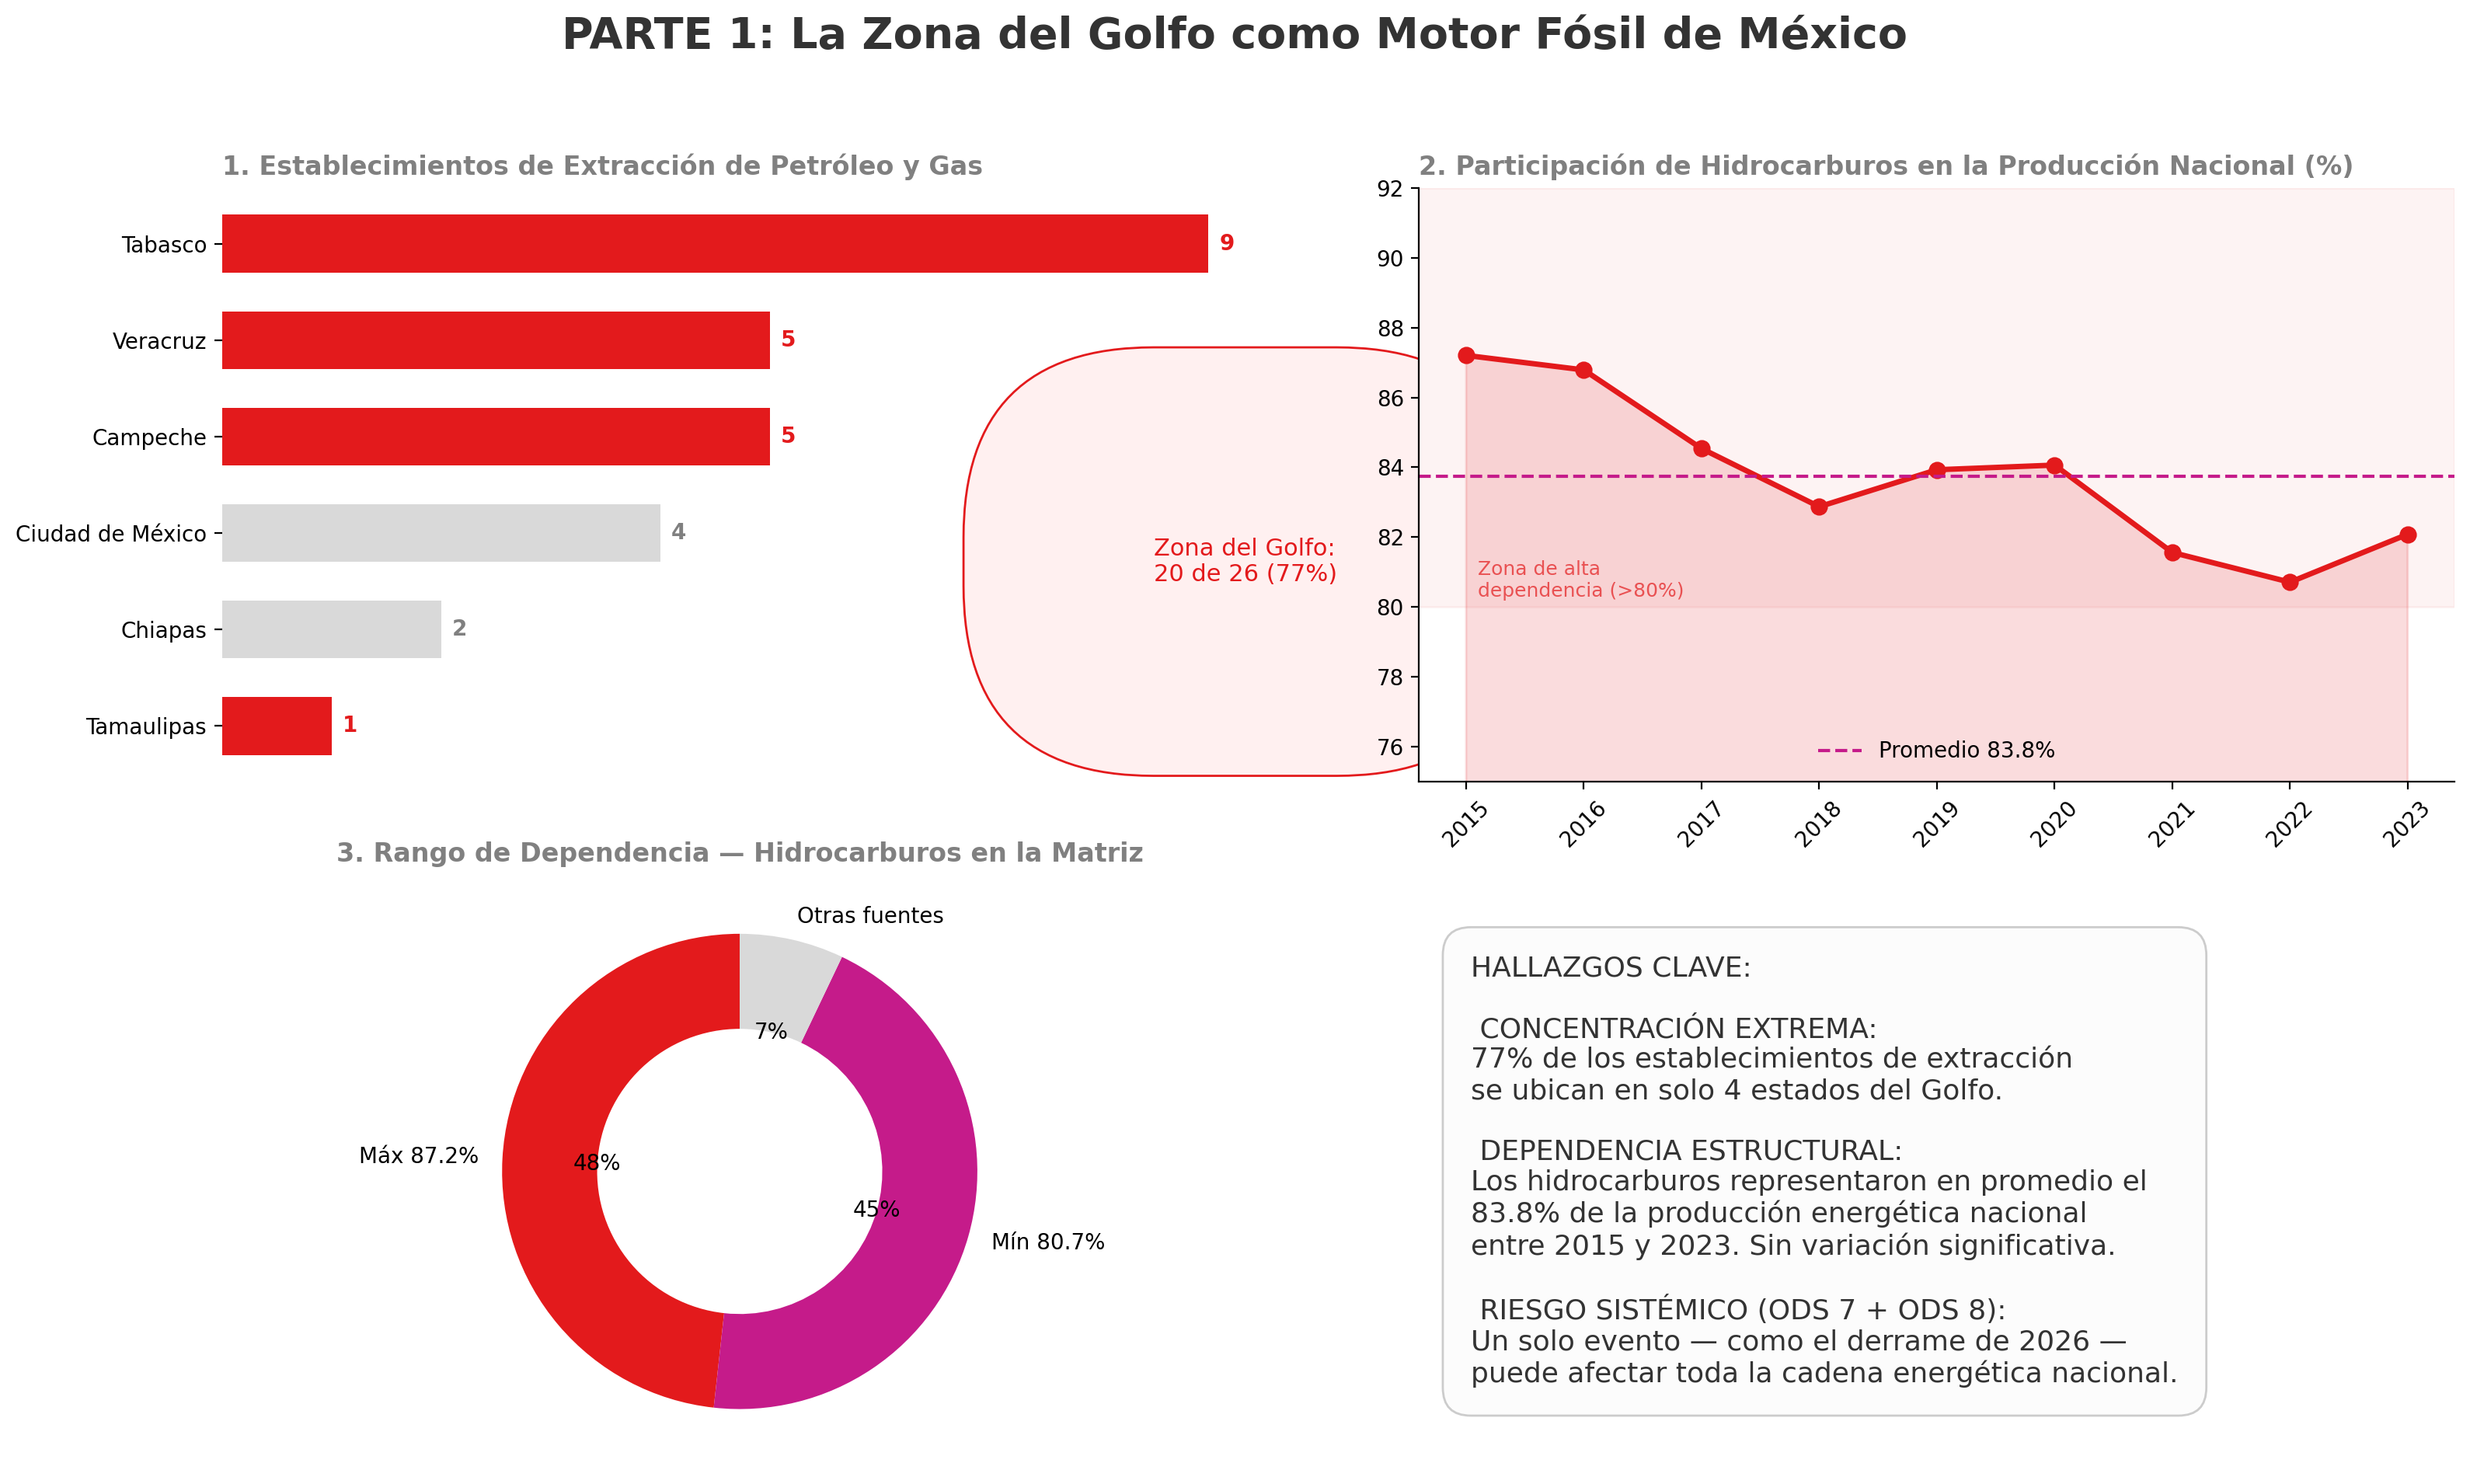

In [4]:
# 2. Dashboard Parte 1 — 2x2 paneles

%config InlineBackend.figure_format = 'retina'
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PARTE 1: La Zona del Golfo como Motor Fósil de México',
             fontsize=20, fontweight='bold', color='#333333')

# ── Panel 1: Unidades económicas por estado ──────────────────────
df_s = dist.sort_values('Economic Unit', ascending=True)
colores_p1 = ['#e31a1c' if g else '#d9d9d9' for g in df_s['zona_golfo']]

axs[0, 0].barh(df_s['estado'], df_s['Economic Unit'],
               color=colores_p1, height=0.6)
axs[0, 0].set_title('1. Establecimientos de Extracción de Petróleo y Gas',
                     loc='left', color='gray', fontweight='bold')
axs[0, 0].spines[['top', 'right', 'bottom', 'left']].set_visible(False)
axs[0, 0].set_xticks([])
for i, v in enumerate(df_s['Economic Unit']):
    color_txt = '#e31a1c' if df_s['zona_golfo'].iloc[i] else 'gray'
    axs[0, 0].text(v + 0.1, i, str(v), va='center',
                   fontweight='bold', color=color_txt)
axs[0, 0].text(8.5, 1.5,
               f'Zona del Golfo:\n{golfo_estab} de {total_estab} ({pct_golfo:.0f}%)',
               fontsize=11, color='#e31a1c',
               bbox=dict(facecolor='#fff0f0', edgecolor='#e31a1c', pad=8, boxstyle='round'))

# ── Panel 2: Serie histórica participación hidrocarburos ─────────
axs[0, 1].fill_between(prod['año'], prod['participacion'],
                        color='#e31a1c', alpha=0.15)
axs[0, 1].plot(prod['año'], prod['participacion'],
               color='#e31a1c', linewidth=2.5, marker='o', markersize=7)
axs[0, 1].axhline(promedio_prod, linestyle='--', color='#c51b8a',
                  linewidth=1.5, label=f'Promedio {promedio_prod:.1f}%')
axs[0, 1].axhspan(80, 92, alpha=0.05, color='#e31a1c')
axs[0, 1].set_title('2. Participación de Hidrocarburos en la Producción Nacional (%)',
                     loc='left', color='gray', fontweight='bold')
axs[0, 1].spines[['top', 'right']].set_visible(False)
axs[0, 1].set_ylim(75, 92)
axs[0, 1].set_xticks(prod['año'])
axs[0, 1].tick_params(axis='x', rotation=45)
axs[0, 1].legend(frameon=False)
axs[0, 1].text(2015.1, 80.3, 'Zona de alta\ndependencia (>80%)',
               fontsize=9, color='#e31a1c', alpha=0.7)

# ── Panel 3: KPI Gauge visual — porcentaje en la matriz nacional ──
max_val = prod['participacion'].max()
min_val = prod['participacion'].min()
gauge_vals = [max_val, min_val, 100 - max_val]
colores_p3 = ['#e31a1c', '#c51b8a', '#d9d9d9']
axs[1, 0].pie(gauge_vals,
              labels=[f'Máx {max_val:.1f}%', f'Mín {min_val:.1f}%', 'Otras fuentes'],
              colors=colores_p3,
              autopct='%1.0f%%', startangle=90,
              wedgeprops=dict(width=0.4))
axs[1, 0].set_title('3. Rango de Dependencia — Hidrocarburos en la Matriz',
                     loc='center', color='gray', fontweight='bold')

# ── Panel 4: Hallazgos clave ──────────────────────────────────────
axs[1, 1].axis('off')
texto = (
    'HALLAZGOS CLAVE:\n\n'
    ' CONCENTRACIÓN EXTREMA:\n'
    f'{pct_golfo:.0f}% de los establecimientos de extracción\n'
    'se ubican en solo 4 estados del Golfo.\n\n'
    ' DEPENDENCIA ESTRUCTURAL:\n'
    f'Los hidrocarburos representaron en promedio el\n'
    f'{promedio_prod:.1f}% de la producción energética nacional\n'
    'entre 2015 y 2023. Sin variación significativa.\n\n'
    ' RIESGO SISTÉMICO (ODS 7 + ODS 8):\n'
    'Un solo evento — como el derrame de 2026 —\n'
    'puede afectar toda la cadena energética nacional.'
)
axs[1, 1].text(0.05, 0.5, texto, fontsize=13, va='center', ha='left',
               color='#333333',
               bbox=dict(facecolor='#fcfcfc', edgecolor='#cccccc',
                         pad=20, boxstyle='round,pad=1'))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---
## Parte 2: Alternativas de Mediano Plazo

El recurso renovable de la región está documentado y ampliamente subutilizado.
Las energías solar y eólica no reemplazan a los hidrocarburos de la noche a la mañana,
pero ofrecen una vía concreta para reducir la concentración de riesgo a mediano plazo.


In [5]:
# 1. Preparación de datos — solar y eólico

# Solar: solo estados del Golfo + Alemania como referencia
solar_golfo = solar[solar['region'].str.contains('Golfo|Costa', case=False)].copy()
solar_ref   = solar[solar['estado'] == 'Alemania'].iloc[0]

# Eólico: excluir Oaxaca (referencia nacional)
eolico_golfo = eolico[~eolico['estado'].str.contains('referencia', case=False)].copy()
tam = eolico_golfo[eolico_golfo['estado'] == 'Tamaulipas'].iloc[0]

print(f"Solar — estados Golfo: {solar_golfo['estado'].tolist()}")
print(f"Radiación Alemania (referencia): {solar_ref['radiacion_promedio_kWh_m2_dia']} kWh/m²/día")
print(f"Tamaulipas eólico — Potencial: {tam['potencial_eolico_MW']:,} MW | Instalado: {tam['capacidad_instalada_2024_MW']} MW")

Solar — estados Golfo: ['Veracruz', 'Tamaulipas', 'Tabasco', 'Campeche']
Radiación Alemania (referencia): 3.0 kWh/m²/día
Tamaulipas eólico — Potencial: 22,558 MW | Instalado: 2.3 MW


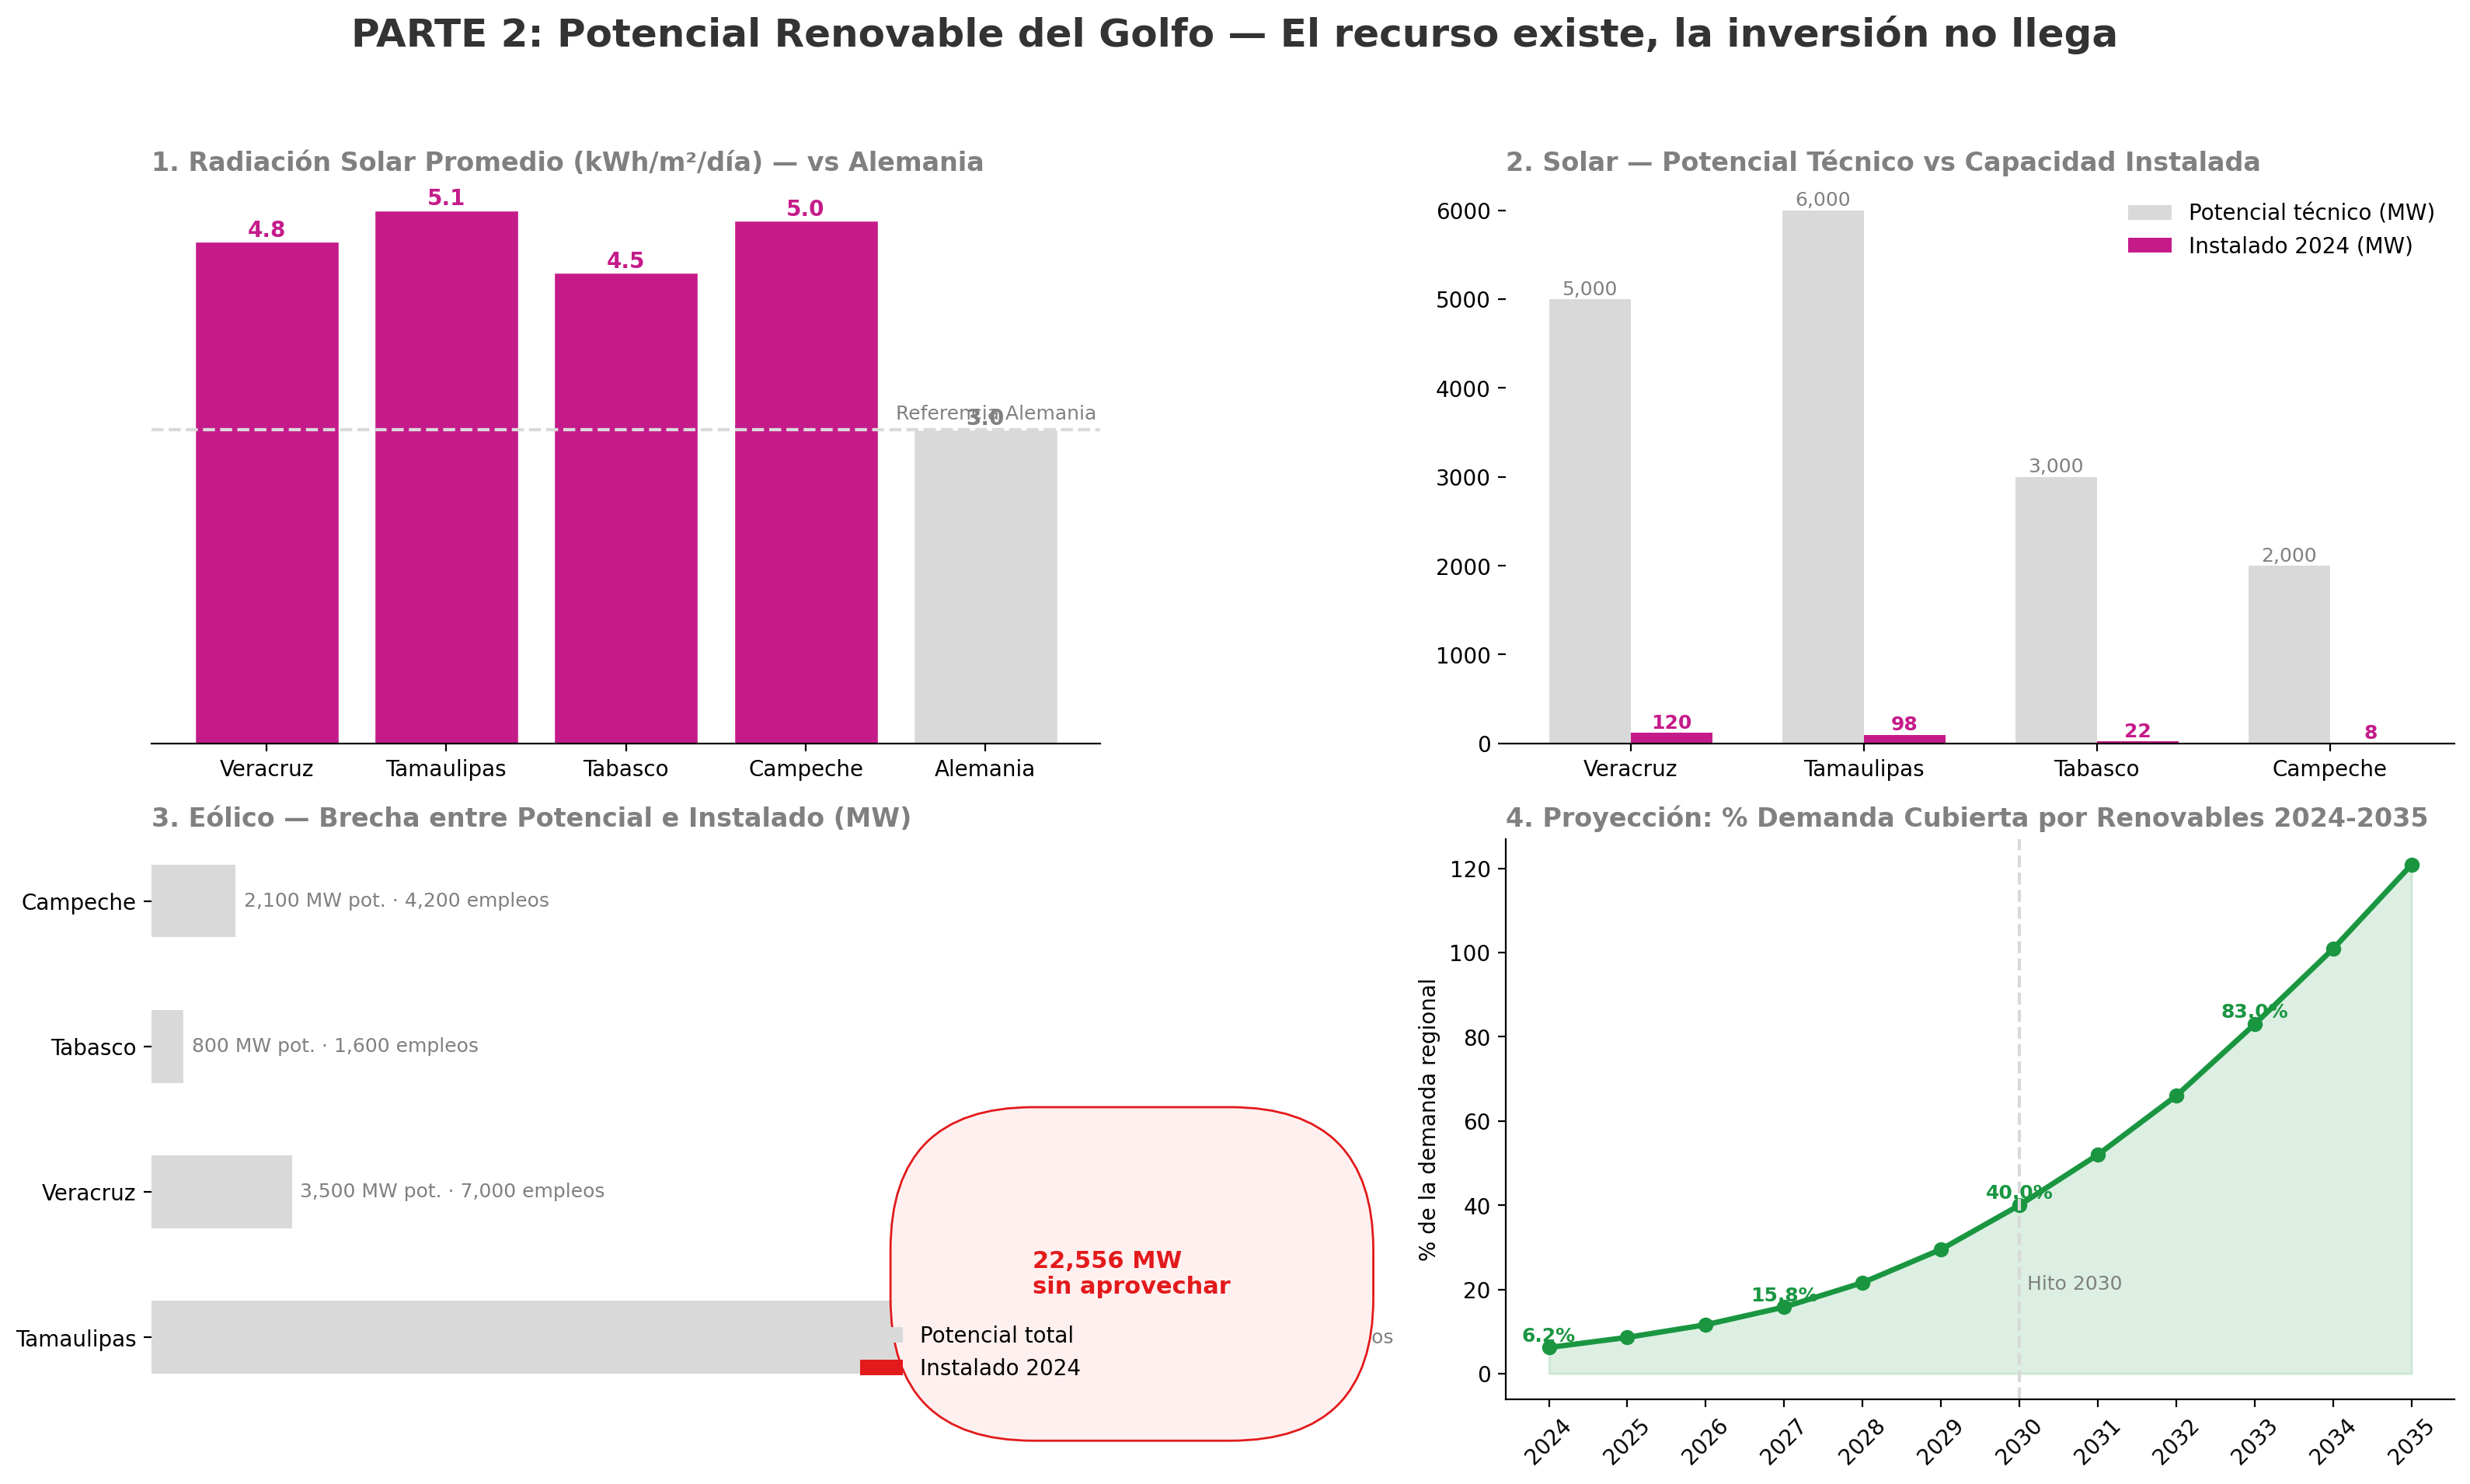

In [6]:
# 2. Dashboard Parte 2 — Solar y Eólico

%config InlineBackend.figure_format = 'retina'
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PARTE 2: Potencial Renovable del Golfo — El recurso existe, la inversión no llega',
             fontsize=18, fontweight='bold', color='#333333')

# ── Panel 1: Radiación solar — Golfo vs Alemania ─────────────────
todos_solar = pd.concat([solar_golfo, solar[solar['estado'] == 'Alemania']])
colores_solar = ['#c51b8a' if r in solar_golfo['estado'].values else '#d9d9d9'
                 for r in todos_solar['estado']]

axs[0, 0].bar(todos_solar['estado'],
              todos_solar['radiacion_promedio_kWh_m2_dia'],
              color=colores_solar, edgecolor='white', linewidth=0.5)
axs[0, 0].set_title('1. Radiación Solar Promedio (kWh/m²/día) — vs Alemania',
                     loc='left', color='gray', fontweight='bold')
axs[0, 0].spines[['top', 'right', 'left']].set_visible(False)
axs[0, 0].set_yticks([])
for i, (estado, val) in enumerate(zip(todos_solar['estado'],
                                       todos_solar['radiacion_promedio_kWh_m2_dia'])):
    axs[0, 0].text(i, val + 0.05, f'{val:.1f}', ha='center',
                   fontweight='bold',
                   color='#c51b8a' if estado in solar_golfo['estado'].values else 'gray')
axs[0, 0].axhline(solar_ref['radiacion_promedio_kWh_m2_dia'],
                   linestyle='--', color='#d9d9d9', linewidth=1.5)
axs[0, 0].text(3.5, solar_ref['radiacion_promedio_kWh_m2_dia'] + 0.1,
               'Referencia Alemania', fontsize=9, color='gray')

# ── Panel 2: Potencial solar vs instalado ────────────────────────
x = np.arange(len(solar_golfo))
w = 0.35
axs[0, 1].bar(x - w/2, solar_golfo['potencial_tecnico_MW'],
              width=w, color='#d9d9d9', label='Potencial técnico (MW)')
axs[0, 1].bar(x + w/2, solar_golfo['capacidad_instalada_2024_MW'],
              width=w, color='#c51b8a', label='Instalado 2024 (MW)')
axs[0, 1].set_title('2. Solar — Potencial Técnico vs Capacidad Instalada',
                     loc='left', color='gray', fontweight='bold')
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(solar_golfo['estado'])
axs[0, 1].spines[['top', 'right', 'left']].set_visible(False)
axs[0, 1].legend(frameon=False)
for i, (pot, inst) in enumerate(zip(solar_golfo['potencial_tecnico_MW'],
                                     solar_golfo['capacidad_instalada_2024_MW'])):
    axs[0, 1].text(i - w/2, pot + 50, f'{pot:,.0f}', ha='center', fontsize=9, color='gray')
    axs[0, 1].text(i + w/2, inst + 50, str(inst), ha='center',
                   fontsize=9, color='#c51b8a', fontweight='bold')

# ── Panel 3: Brecha eólica ────────────────────────────────────────
colores_eol = ['#e31a1c' if e == 'Tamaulipas' else '#d9d9d9'
               for e in eolico_golfo['estado']]
axs[1, 0].barh(eolico_golfo['estado'], eolico_golfo['potencial_eolico_MW'],
               color='#d9d9d9', height=0.5, label='Potencial total')
axs[1, 0].barh(eolico_golfo['estado'], eolico_golfo['capacidad_instalada_2024_MW'],
               color=colores_eol, height=0.5, label='Instalado 2024')
axs[1, 0].set_title('3. Eólico — Brecha entre Potencial e Instalado (MW)',
                     loc='left', color='gray', fontweight='bold')
axs[1, 0].spines[['top', 'right', 'bottom', 'left']].set_visible(False)
axs[1, 0].set_xticks([])
for i, row in eolico_golfo.reset_index().iterrows():
    axs[1, 0].text(row['potencial_eolico_MW'] + 200, i,
                   f"{row['potencial_eolico_MW']:,} MW pot. · {row['empleos_potencial']:,} empleos",
                   va='center', fontsize=9, color='gray')
axs[1, 0].text(22000, 0.3,
               f'{tam["brecha_MW"]:,.0f} MW\nsin aprovechar',
               fontsize=11, color='#e31a1c', fontweight='bold',
               bbox=dict(facecolor='#fff0f0', edgecolor='#e31a1c', pad=6, boxstyle='round'))
axs[1, 0].legend(frameon=False, loc='lower right')

# ── Panel 4: Proyección 2024-2035 ────────────────────────────────
axs[1, 1].fill_between(proy['año'], proy['pct_demanda_cubierta'],
                        alpha=0.15, color='#1a9641')
axs[1, 1].plot(proy['año'], proy['pct_demanda_cubierta'],
               color='#1a9641', linewidth=2.5, marker='o', markersize=6)
axs[1, 1].axvline(2030, linestyle='--', color='#d9d9d9', linewidth=1.5)
axs[1, 1].text(2030.1, 20, 'Hito 2030', fontsize=9, color='gray')
axs[1, 1].set_title('4. Proyección: % Demanda Cubierta por Renovables 2024-2035',
                     loc='left', color='gray', fontweight='bold')
axs[1, 1].spines[['top', 'right']].set_visible(False)
axs[1, 1].set_xticks(proy['año'])
axs[1, 1].tick_params(axis='x', rotation=45)
axs[1, 1].set_ylabel('% de la demanda regional')
for año, pct in zip(proy['año'], proy['pct_demanda_cubierta']):
    if año in [2024, 2027, 2030, 2033]:
        axs[1, 1].text(año, pct + 1.5, f'{pct:.1f}%', ha='center',
                       fontsize=9, color='#1a9641', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Comparativa directa: Renovables vs Hidrocarburos

Siete indicadores clave muestran dónde las alternativas renovables superan
estructuralmente al modelo actual — no en escala, sino en costo, riesgo y empleos.


In [7]:
# 1. Preparar datos de comparativa

def a_numero(val):
    try:
        return float(str(val).split(' ')[0].replace(',', ''))
    except:
        return np.nan

renov['solar_n']  = renov['solar_golfo'].apply(a_numero)
renov['eolico_n'] = renov['eolico_golfo'].apply(a_numero)
renov['hidro_n']  = renov['hidrocarburos_golfo'].apply(a_numero)

kpis = [
    dict(idx=2,  label='Costo LCOE\n(USD/MWh)',        menor_mejor=True),
    dict(idx=3,  label='Emisiones CO₂\n(gCO₂/kWh)',    menor_mejor=True),
    dict(idx=6,  label='Riesgo ambiental\n(1-10)',      menor_mejor=True),
    dict(idx=8,  label='Tiempo construcción\n(meses)',  menor_mejor=True),
    dict(idx=1,  label='Empleos directos',               menor_mejor=False),
    dict(idx=4,  label='Vida útil (años)',               menor_mejor=False),
    dict(idx=5,  label='Derrama económica\nlocal (%)',  menor_mejor=False),
]
print('Indicadores preparados:', len(kpis))

Indicadores preparados: 7


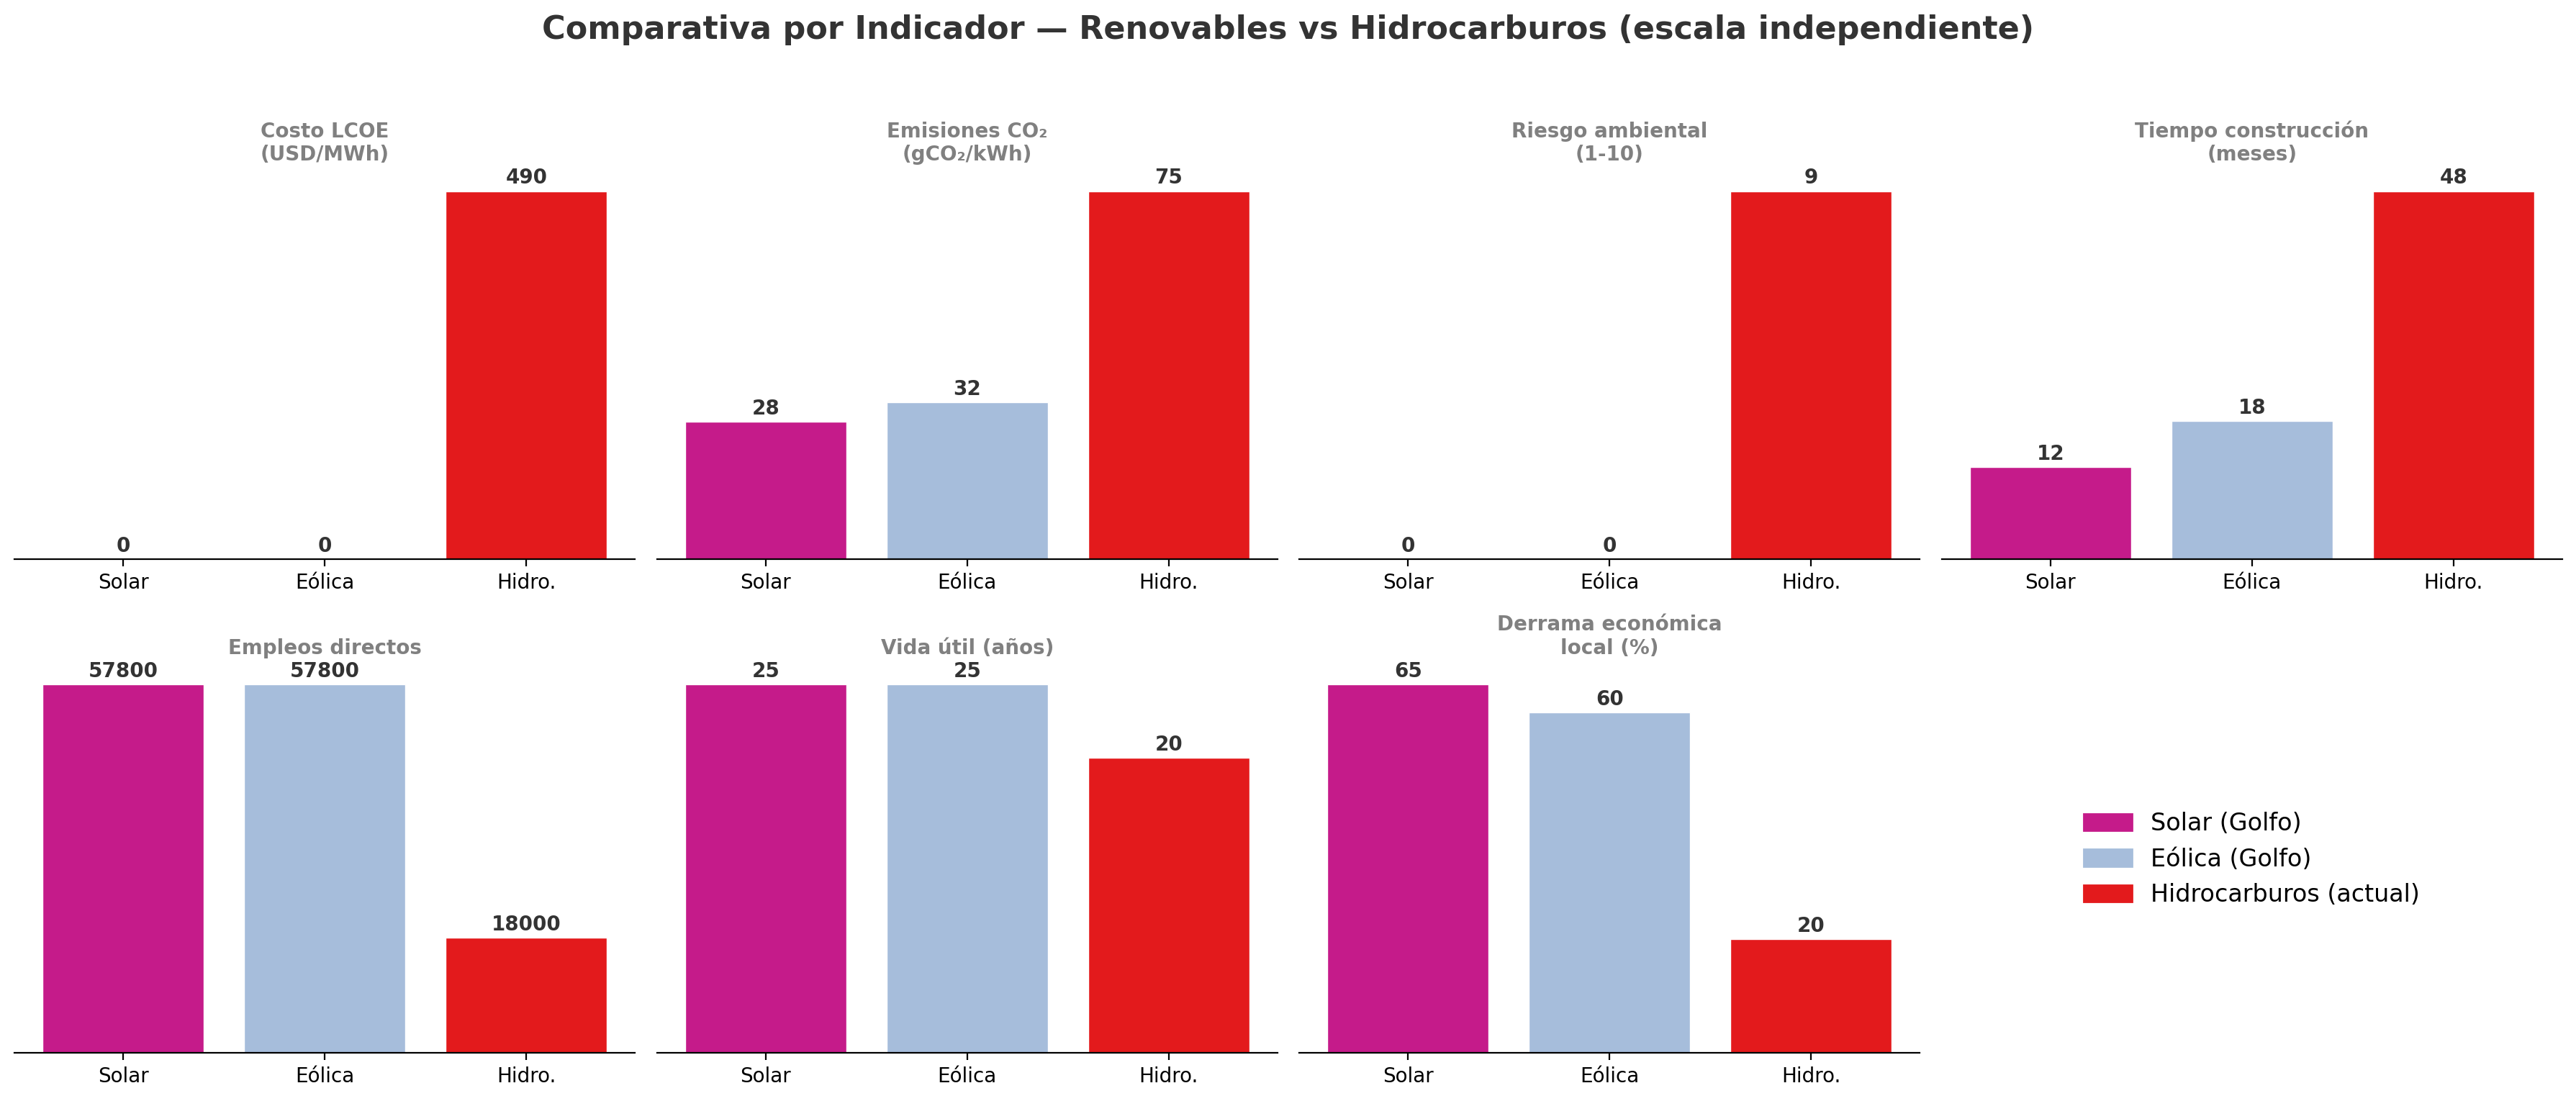

In [8]:
# 2. Dashboard KPIs — un panel por indicador (escala independiente)

%config InlineBackend.figure_format = 'retina'
fig, axs = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Comparativa por Indicador — Renovables vs Hidrocarburos (escala independiente)',
             fontsize=16, fontweight='bold', color='#333333')

categorias  = ['Solar', 'Eólica', 'Hidro.']
colores_bar = ['#c51b8a', '#a6bddb', '#e31a1c']

for i, kpi in enumerate(kpis):
    row = i // 4
    col = i % 4
    fila = renov.iloc[kpi['idx']]
    vals = [fila['solar_n'], fila['eolico_n'], fila['hidro_n']]

    bars = axs[row, col].bar(categorias, vals, color=colores_bar,
                              edgecolor='white', linewidth=0.5)
    axs[row, col].set_title(kpi['label'], loc='center', color='gray',
                             fontweight='bold', fontsize=10)
    axs[row, col].spines[['top', 'right', 'left']].set_visible(False)
    axs[row, col].set_yticks([])

    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            axs[row, col].text(bar.get_x() + bar.get_width()/2,
                               bar.get_height() + max(vals) * 0.02,
                               str(int(val)), ha='center', fontsize=10,
                               fontweight='bold', color='#333333')

# Celda extra vacía (2,3) → leyenda
axs[1, 3].axis('off')
leyenda = [
    mpatches.Patch(color='#c51b8a', label='Solar (Golfo)'),
    mpatches.Patch(color='#a6bddb', label='Eólica (Golfo)'),
    mpatches.Patch(color='#e31a1c', label='Hidrocarburos (actual)'),
]
axs[1, 3].legend(handles=leyenda, frameon=False, fontsize=12, loc='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---
*Notebook generado para HackODS 2026 · SamsanTech · Rodolfo Renteria*